In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine("mysql+pymysql://root:@127.0.0.1/ocd_analysis")
df = pd.read_sql("SELECT * FROM ocd_patient_dataset", engine)


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Kết nối đến MySQL trên Mac M1
engine = create_engine("mysql+pymysql://root:@127.0.0.1/ocd_analysis")

# Lấy dữ liệu thô
df = pd.read_sql("SELECT * FROM ocd_patient_dataset", engine)

# Tính tổng điểm Y-BOCS theo công thức chuẩn
# $$Total\_Score = Score_{Obsession} + Score_{Compulsion}$$
df['Total_Score'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65136/104528355.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Severity', order=order, palette='viridis')


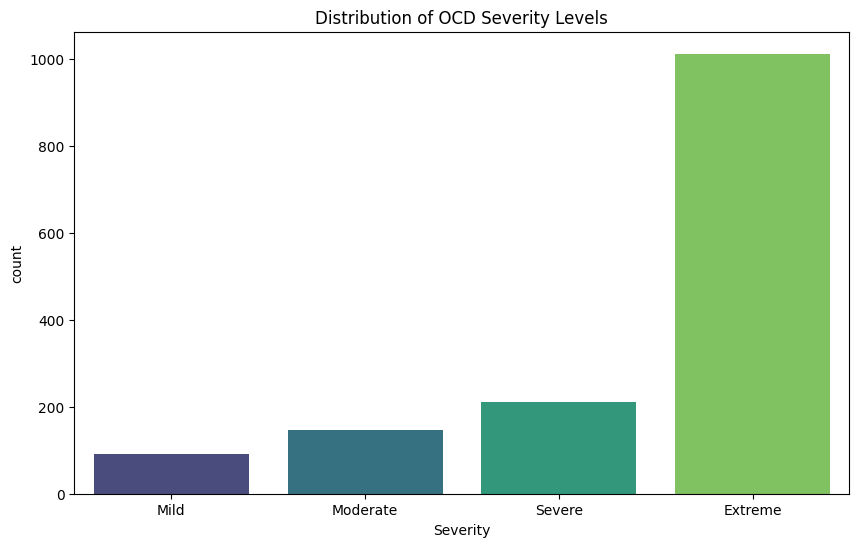

In [3]:
# Phân nhóm mức độ dựa trên tiêu chuẩn Y-BOCS
def classify_severity(score):
    if score <= 7: return 'Subclinical'
    if score <= 15: return 'Mild'
    if score <= 23: return 'Moderate'
    if score <= 31: return 'Severe'
    return 'Extreme'

df['Severity'] = df['Total_Score'].apply(classify_severity)

plt.figure(figsize=(10, 6))
order = ['Mild', 'Moderate', 'Severe', 'Extreme']
sns.countplot(data=df, x='Severity', order=order, palette='viridis')
plt.title('Distribution of OCD Severity Levels')
plt.show()

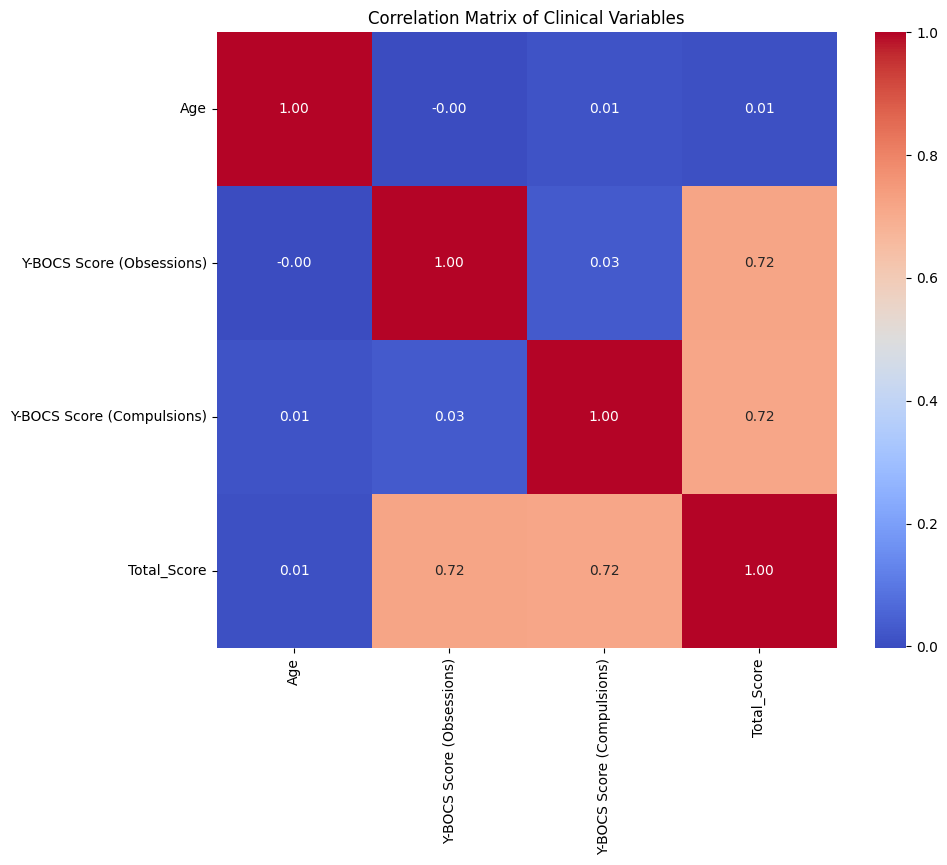

In [4]:
plt.figure(figsize=(10, 8))
# Chọn các cột định lượng để tính tương quan
corr = df[['Age', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)', 'Total_Score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Clinical Variables')
plt.show()

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65136/2968847092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Total_Score', palette='Set2')


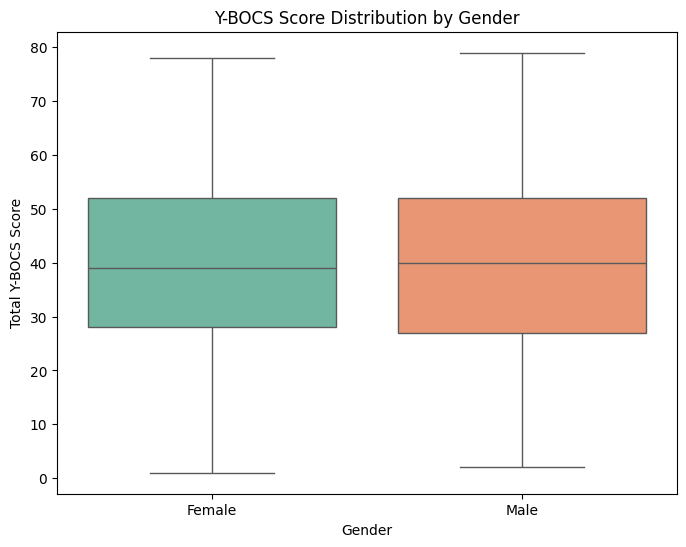

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Total_Score', palette='Set2')
plt.title('Y-BOCS Score Distribution by Gender')
plt.ylabel('Total Y-BOCS Score')
plt.show()

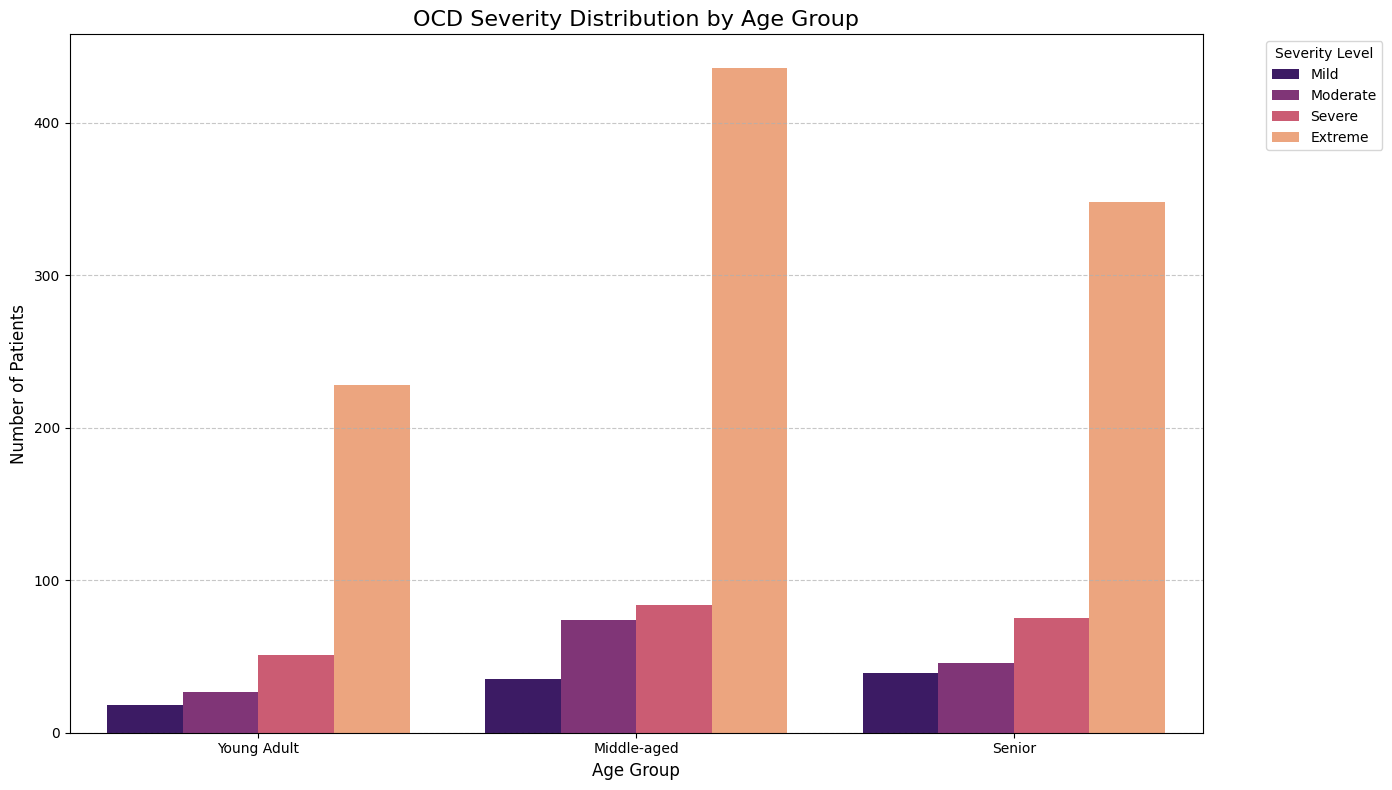

In [12]:
# 2. Tính toán các cột bổ sung
df['Total_Score'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

# Phân nhóm mức độ bệnh (Severity)
def get_severity(score):
    if score <= 7: return 'Subclinical'
    if score <= 15: return 'Mild'
    if score <= 23: return 'Moderate'
    if score <= 31: return 'Severe'
    return 'Extreme'

# Phân nhóm tuổi (Age Group)
def get_age_group(age):
    if age <= 30: return 'Young Adult'
    if age <= 55: return 'Middle-aged'
    return 'Senior'

df['Severity'] = df['Total_Score'].apply(get_severity)
df['Age_Group'] = df['Age'].apply(get_age_group)

# 3. Trực quan hóa
plt.figure(figsize=(14, 8))

# Sắp xếp thứ tự hiển thị cho chuyên nghiệp
age_order = ['Young Adult', 'Middle-aged', 'Senior']
severity_order = ['Mild', 'Moderate', 'Severe', 'Extreme']

# Vẽ biểu đồ cột chồng (Stacked Bar Chart) thể hiện tỷ lệ mức độ trong từng nhóm tuổi
sns.countplot(data=df, x='Age_Group', hue='Severity', 
              order=age_order, hue_order=severity_order, palette='magma')

plt.title('OCD Severity Distribution by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65136/2213747421.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y='Age', order=severity_order,


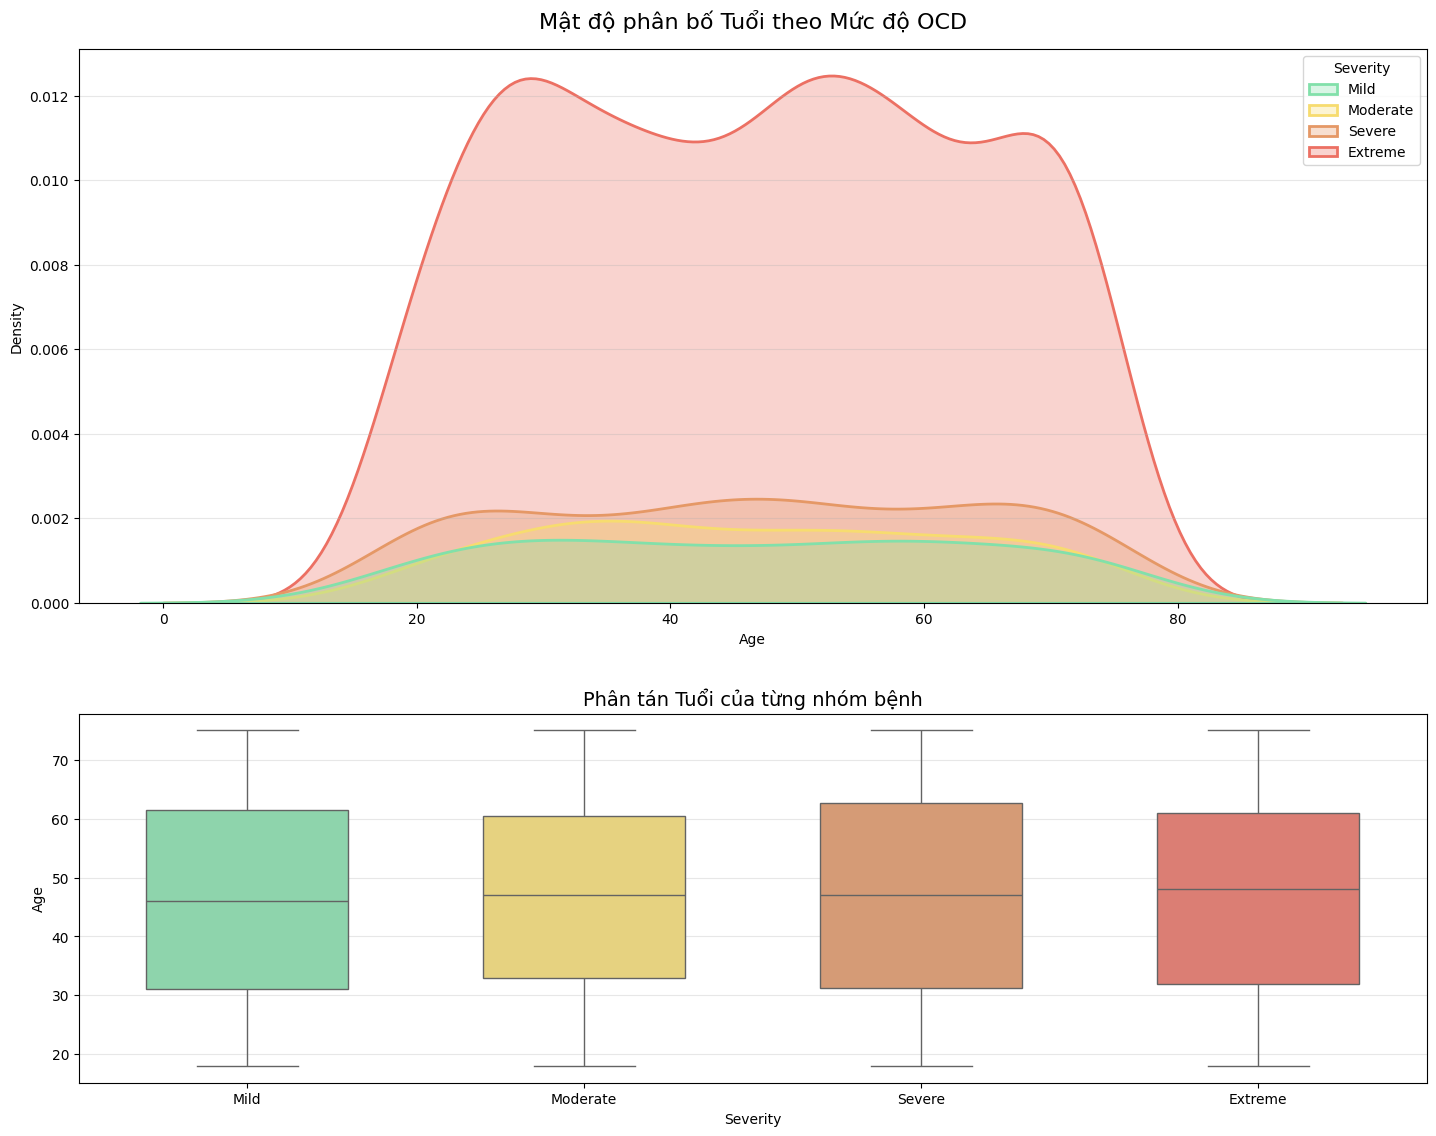

Thống kê mô tả Tuổi theo từng mức độ bệnh:


,count,mean,std,min,25%,50%,75%,max
Severity,,,,,,,,
Mild,131.0,46.786260,17.509122,18.0,31.00,46.0,61.50,75.0
Moderate,147.0,46.598639,16.159165,18.0,33.00,47.0,60.50,75.0
Severe,210.0,46.928571,17.478891,18.0,31.25,47.0,62.75,75.0
Extreme,1012.0,46.776680,16.723963,18.0,32.00,48.0,61.00,75.0


In [ ]:
df['Severity'] = df['Total_Score'].apply(classify_severity)

# 2. Thiết lập màu sắc và thứ tự cho 4 mức độ
colors = ['#82E0AA', '#F7DC6F', '#E59866', '#EC7063'] # Xanh -> Vàng -> Cam -> Đỏ
severity_order = ['Mild', 'Moderate', 'Severe', 'Extreme']

# 3. Vẽ biểu đồ kết hợp (KDE + Boxplot)
fig, axes = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [1.5, 1]})

# Biểu đồ KDE: Xem mật độ tập trung tuổi của từng nhóm
sns.kdeplot(data=df, x='Age', hue='Severity', hue_order=severity_order, 
            palette=colors, fill=True, alpha=0.3, ax=axes[0], linewidth=2)
axes[0].set_title('Mật độ phân bố Tuổi theo Mức độ OCD', fontsize=16, pad=15)
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ Boxplot: Xem các chỉ số thống kê (Trung vị, Ngoại lai)
sns.boxplot(data=df, x='Severity', y='Age', order=severity_order, 
            palette=colors, ax=axes[1], width=0.6)
axes[1].set_title('Phân tán Tuổi của từng nhóm bệnh', fontsize=14)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

# 4. Hiển thị bảng thống kê mô tả chi tiết
print("Thống kê mô tả Tuổi theo từng mức độ bệnh:")
display(df.groupby('Severity')['Age'].describe().reindex(severity_order))

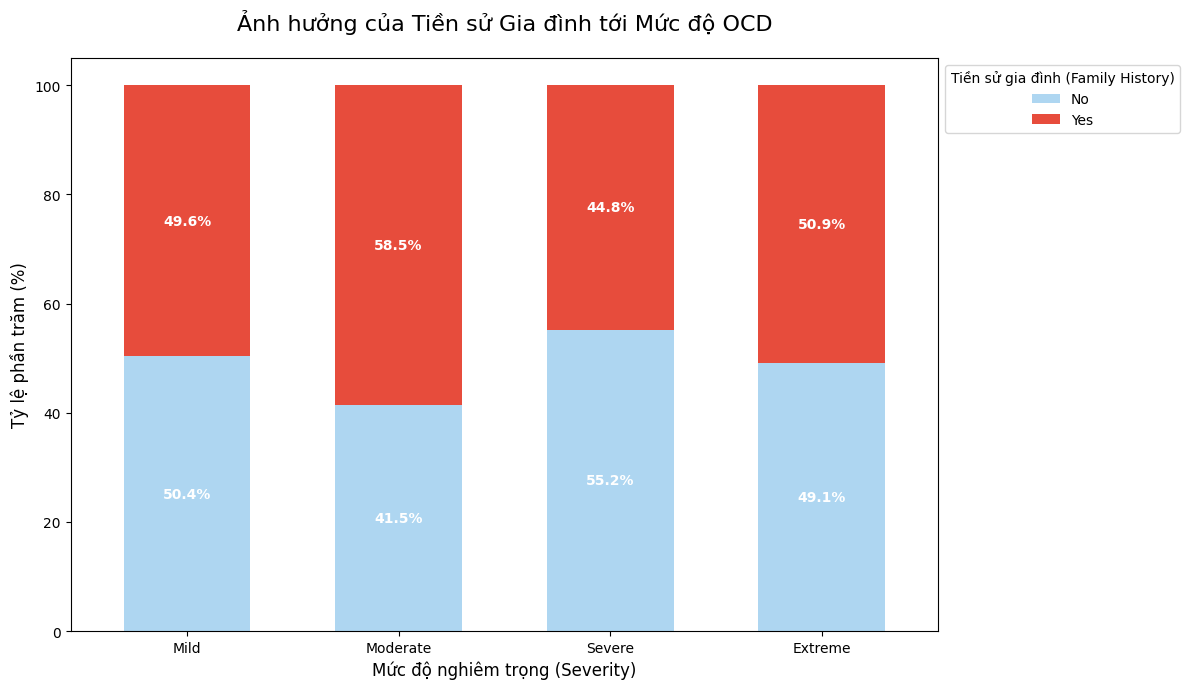

In [15]:
# 2. Tạo bảng chéo (Crosstab) tính tỷ lệ phần trăm
# Tính toán xem trong mỗi nhóm Severity, bao nhiêu % là Yes/No cho Family History
ct = pd.crosstab(df['Severity'], df['Family History of OCD'], normalize='index') * 100
ct = ct.reindex(severity_order)

# 3. Vẽ biểu đồ cột chồng phần trăm (100% Stacked Bar Chart)
ax = ct.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#AED6F1', '#E74C3C'], width=0.6)

# Cấu trúc biểu đồ
plt.title('Ảnh hưởng của Tiền sử Gia đình tới Mức độ OCD', fontsize=16, pad=20)
plt.xlabel('Mức độ nghiêm trọng (Severity)', fontsize=12)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Tiền sử gia đình (Family History)', bbox_to_anchor=(1, 1))

# Thêm nhãn số phần trăm lên các cột
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65136/2924090510.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Family History of OCD', y='Total_Score', palette='vlag')


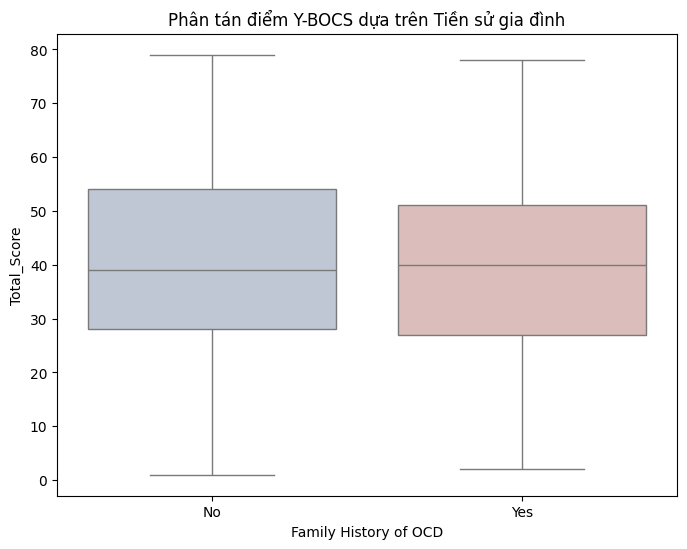

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Family History of OCD', y='Total_Score', palette='vlag')
plt.title('Phân tán điểm Y-BOCS dựa trên Tiền sử gia đình')
plt.show()

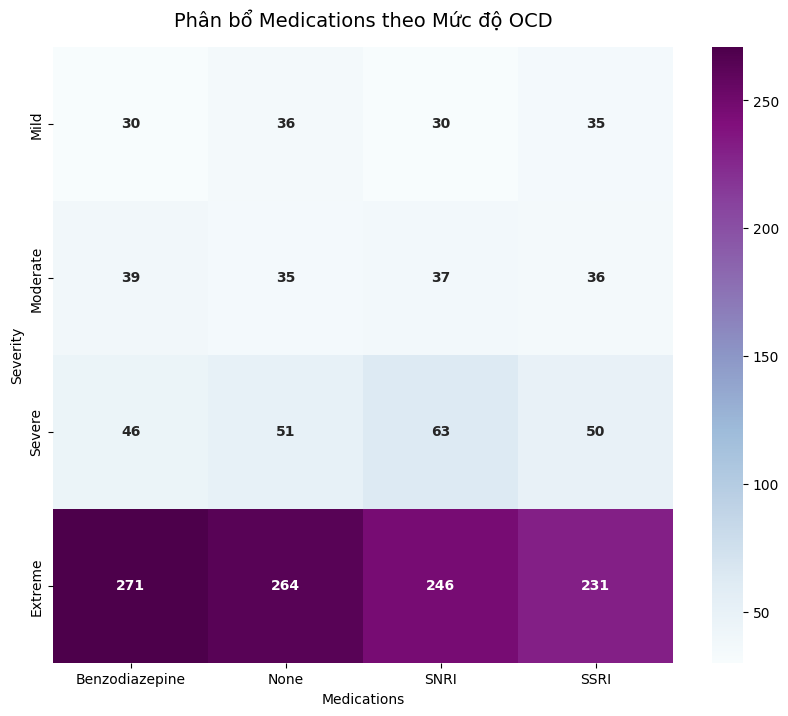

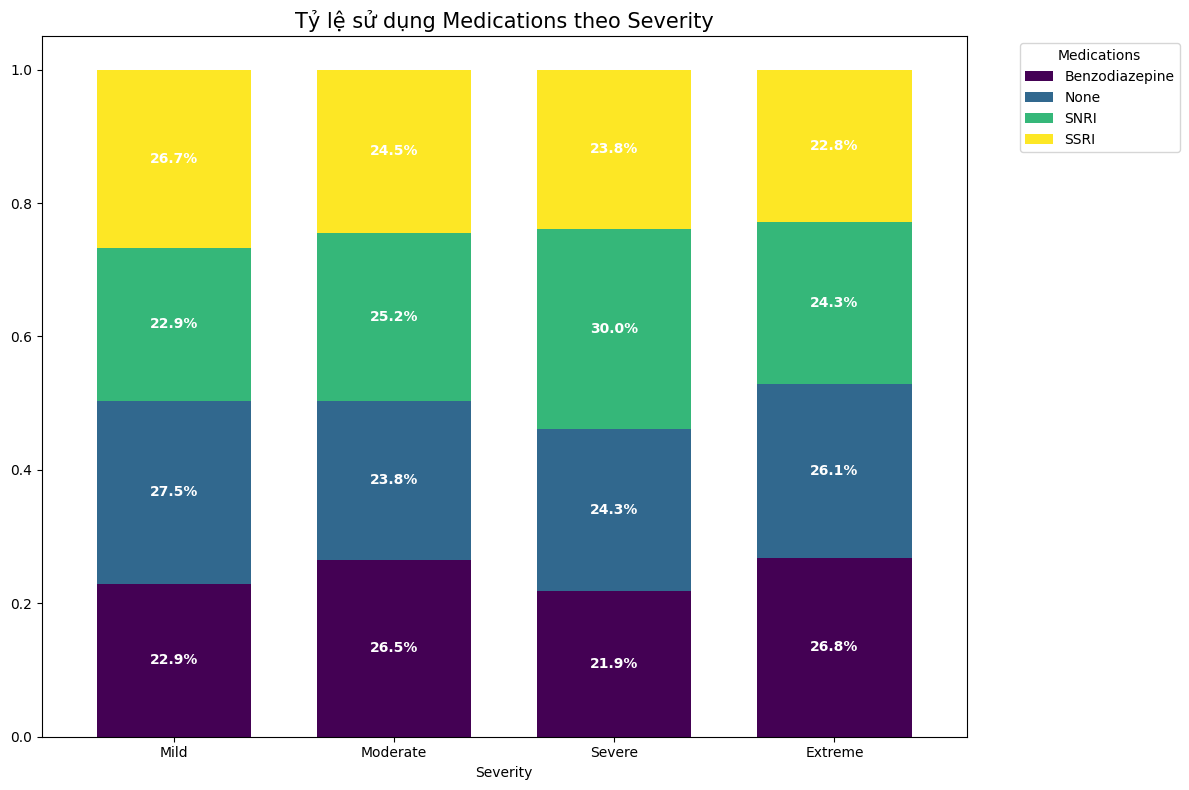

In [ ]:
# 1. Kiểm tra và chuẩn bị bảng chéo
severity_order = ['Mild', 'Moderate', 'Severe', 'Extreme']

# Sửa 'Medication' thành 'Medications' (hoặc tên chính xác bạn vừa print ở trên)
target_col = 'Medications' if 'Medications' in df.columns else 'Medication'

medication_crosstab = pd.crosstab(df['Severity'], df[target_col]).reindex(severity_order)

# 2. Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(medication_crosstab, annot=True, fmt='d', cmap='BuPu', annot_kws={'weight': 'bold'})
plt.title(f'Phân bổ {target_col} theo Mức độ OCD', fontsize=14, pad=15)
plt.show()

# 3. Vẽ Stacked Bar Chart với tỷ lệ %
medication_prop = pd.crosstab(df['Severity'], df[target_col], normalize='index').reindex(severity_order)
ax = medication_prop.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis', width=0.7)

plt.title(f'Tỷ lệ sử dụng {target_col} theo Severity', fontsize=15)
plt.xticks(rotation=0)
plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')

# Thêm nhãn %
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0.02:
        ax.text(p.get_x() + width/2, p.get_y() + height/2, f'{height:.1%}', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()